In [1]:
import json
import os
import random
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from sentence_transformers import SentenceTransformer
from InstructorEmbedding import INSTRUCTOR
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Random seed: {SEED}")
print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")
if DEVICE == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

c:\Users\Admin\miniconda3\envs\instructor\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Random seed: 42
Device: cpu
PyTorch version: 2.9.1+cpu


In [2]:
medi_path = "input/medi-data.json"

print(f"Đang load MEDI data từ: {medi_path}")

with open(medi_path, 'r', encoding='utf-8') as f:
    medi_data = json.load(f)

print(f"\n✅ Load thành công!")
print(f"Số lượng samples: {len(medi_data):,}")

sample = medi_data[0]
print(f"\nKeys của sample đầu tiên: {list(sample.keys())}")
print(f"\nSample đầu tiên:")
for key, value in sample.items():
    val_str = str(value)[:100] + "..." if len(str(value)) > 100 else str(value)
    print(f"  {key}: {val_str}")

Đang load MEDI data từ: input/medi-data.json
(File ~2.7GB, có thể mất vài phút...)

✅ Load thành công!
Type: <class 'list'>
Số lượng samples: 1,435,000

Keys của sample đầu tiên: ['query', 'pos', 'neg', 'task_name']

Sample đầu tiên:
  query: ['Represent the Wikipedia question for retrieving relevant documents;', 'big little lies season 2 ho...
  pos: ['Represent the Wikipedia document for retrieval;', 'Big Little Lies (TV series) series garnered sev...
  neg: ['Represent the Wikipedia document for retrieval;', 'Little People, Big World final minutes of the s...
  task_name: NQ


In [3]:
def normalize_sample(sample):
    result = {
        'text_x': None,
        'text_pos': None,
        'text_neg': None,
        'instruction_x': None,
        'instruction_pos': None,
        'instruction_neg': None,
        'task_name': None,
    }
    
    if 'query' in sample and isinstance(sample['query'], list) and len(sample['query']) >= 2:
        result['instruction_x'] = sample['query'][0]
        result['text_x'] = sample['query'][1]
    elif 'query' in sample and isinstance(sample['query'], str):
        result['text_x'] = sample['query']
    
    if 'pos' in sample and isinstance(sample['pos'], list) and len(sample['pos']) >= 2:
        result['instruction_pos'] = sample['pos'][0]
        result['text_pos'] = sample['pos'][1]
    elif 'pos' in sample and isinstance(sample['pos'], str):
        result['text_pos'] = sample['pos']
    
    if 'neg' in sample and isinstance(sample['neg'], list) and len(sample['neg']) >= 2:
        result['instruction_neg'] = sample['neg'][0]
        result['text_neg'] = sample['neg'][1]
    elif 'neg' in sample and isinstance(sample['neg'], str):
        result['text_neg'] = sample['neg']
    
    for key in ['task_name', 'task', 'dataset', 'dataset_name']:
        if key in sample and sample[key]:
            result['task_name'] = sample[key]
            break
    
    return result

NUM_SAMPLES = min(50000, len(medi_data))
print(f"Đang normalize {NUM_SAMPLES:,} samples...")

normalized_samples = [normalize_sample(s) for s in medi_data[:NUM_SAMPLES]]
df = pd.DataFrame(normalized_samples)

print(f"\nDataFrame shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nThống kê task_name:")
print(df['task_name'].value_counts().head(15))
print(f"\n5 samples đầu tiên:")
df.head()

Đang normalize 50,000 samples...

✅ DataFrame shape: (50000, 7)

Columns: ['text_x', 'text_pos', 'text_neg', 'instruction_x', 'instruction_pos', 'instruction_neg', 'task_name']

Thống kê task_name:
task_name
NQ    50000
Name: count, dtype: int64

5 samples đầu tiên:


,text_x,text_pos,text_neg,instruction_x,instruction_pos,instruction_neg,task_name
0,big little lies season 2 how many episodes,Big Little Lies (TV series) series garnered se...,"Little People, Big World final minutes of the ...",Represent the Wikipedia question for retrievin...,Represent the Wikipedia document for retrieval;,Represent the Wikipedia document for retrieval;,NQ
1,who sang waiting for a girl like you,Waiting for a Girl Like You Waiting for a Girl...,Waiting for a Girl Like You held off the numbe...,Represent the Wikipedia question for retrievin...,Represent the Wikipedia document for retrieval;,Represent the Wikipedia document for retrieval;,NQ
2,where do you cross the arctic circle in norway,Arctic Norway Arctic Norway Arctic Norway () c...,Arctic Circle Circle is divided among 8 countr...,Represent the Wikipedia question for retrievin...,Represent the Wikipedia document for retrieval;,Represent the Wikipedia document for retrieval;,NQ
3,who is the main character in green eggs and ham,"Green Eggs and Ham (in a house, in a box, in a...",Fox in Socks Fox in Socks Fox in Socks is a ch...,Represent the Wikipedia question for retrievin...,Represent the Wikipedia document for retrieval;,Represent the Wikipedia document for retrieval;,NQ
4,do veins carry blood to the heart or away,Vein Vein Veins are blood vessels that carry b...,Venae cavae superior vena cava (or cranial ven...,Represent the Wikipedia question for retrievin...,Represent the Wikipedia document for retrieval;,Represent the Wikipedia document for retrieval;,NQ


In [4]:
sentiment_keywords = ['amazon', 'imdb', 'polarity', 'sentiment', 'emotion', 'review', 'sst', 'yelp']

def has_sentiment_keyword(task_name):
    if task_name is None:
        return False
    task_lower = task_name.lower()
    return any(kw in task_lower for kw in sentiment_keywords)

task_counts = df['task_name'].value_counts()
sentiment_tasks = [task for task in task_counts.index if has_sentiment_keyword(task)]

print("Các task có keyword sentiment:")
for task in sentiment_tasks[:10]:
    print(f"  {task}: {task_counts[task]} samples")

if sentiment_tasks:
    selected_task = sentiment_tasks[0]
else:
    selected_task = task_counts.index[0]
    print(f"\nKhông tìm thấy sentiment task, fallback sang: {selected_task}")

print(f"\n✅ Task được chọn: {selected_task}")

df_sent = df[df['task_name'] == selected_task].copy()
print(f"Số samples: {len(df_sent)}")


texts_with_labels = []
instructions = []

for idx, row in df_sent.iterrows():
    if row['text_pos'] and isinstance(row['text_pos'], str) and len(row['text_pos']) > 10:
        texts_with_labels.append({'text': row['text_pos'], 'label': 1, 'label_name': 'positive'})
        instructions.append(row['instruction_pos'])
    if row['text_neg'] and isinstance(row['text_neg'], str) and len(row['text_neg']) > 10:
        texts_with_labels.append({'text': row['text_neg'], 'label': 0, 'label_name': 'negative'})
        instructions.append(row['instruction_neg'])

df_sentiment = pd.DataFrame(texts_with_labels)

MAX_PER_CLASS = 200
df_pos = df_sentiment[df_sentiment['label'] == 1].head(MAX_PER_CLASS)
df_neg = df_sentiment[df_sentiment['label'] == 0].head(MAX_PER_CLASS)
df_sentiment = pd.concat([df_pos, df_neg]).reset_index(drop=True)

df_sentiment = df_sentiment.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\n📊 Thống kê sau khi cân bằng:")
print(f"Tổng số samples: {len(df_sentiment)}")
print(f"Phân bố label:")
print(df_sentiment['label_name'].value_counts())

print(f"\n📝 5 ví dụ:")
for i, row in df_sentiment.head(5).iterrows():
    text_short = row['text'][:80] + "..." if len(row['text']) > 80 else row['text']
    print(f"  [{row['label_name']:>8}] {text_short}")

Các task có keyword sentiment:

Không tìm thấy sentiment task, fallback sang: NQ

✅ Task được chọn: NQ
Số samples: 50000

📊 Thống kê sau khi cân bằng:
Tổng số samples: 400
Phân bố label:
label_name
negative    200
positive    200
Name: count, dtype: int64

📝 5 ví dụ:
  [negative] Pendleton Civil Service Reform Act Pendleton Civil Service Reform Act The Pendle...
  [negative] Hysteria (Def Leppard album) worldwide media coverage surrounding it. It is also...
  [positive] Charlie and the Chocolate Factory (film) Attenborough, Kirk Douglas, Albert Finn...
  [negative] Manifest destiny in a limited area". In July 1848, Alexander Stephens denounced ...
  [positive] Audie Murphy Audie Murphy Audie Leon Murphy (20 June 1925 – 28 May 1971) was one...


In [5]:
sample_instruction = None
for inst in instructions:
    if inst and isinstance(inst, str) and len(inst) > 5:
        sample_instruction = inst
        break

print(f"Instruction từ MEDI data: {sample_instruction}")

if sample_instruction is None or 'Represent' not in sample_instruction:
    INSTRUCTION = "Represent the document for retrieval:"
else:
    INSTRUCTION = sample_instruction

print(f"\n✅ Instruction sẽ sử dụng:")
print(f"   \"{INSTRUCTION}\"")

texts = df_sentiment['text'].tolist()
labels = df_sentiment['label'].tolist()
label_names = df_sentiment['label_name'].tolist()

pairs_with_inst = [[INSTRUCTION, text] for text in texts]

texts_plain = texts.copy()

pairs_empty_inst = [["", text] for text in texts]

print(f"\n📊 Đã chuẩn bị:")
print(f"   - pairs_with_inst: {len(pairs_with_inst)} samples (INSTRUCTOR + instruction)")
print(f"   - texts_plain: {len(texts_plain)} samples (GTR-T5, không instruction)")
print(f"   - pairs_empty_inst: {len(pairs_empty_inst)} samples (INSTRUCTOR, instruction rỗng)")

print(f"\n📝 Ví dụ input:")
print(f"   With inst: {pairs_with_inst[0]}")
print(f"   Plain text: {texts_plain[0][:80]}...")

Instruction từ MEDI data: Represent the Wikipedia document for retrieval;

✅ Instruction sẽ sử dụng:
   "Represent the Wikipedia document for retrieval;"

📊 Đã chuẩn bị:
   - pairs_with_inst: 400 samples (INSTRUCTOR + instruction)
   - texts_plain: 400 samples (GTR-T5, không instruction)
   - pairs_empty_inst: 400 samples (INSTRUCTOR, instruction rỗng)

📝 Ví dụ input:
   With inst: ['Represent the Wikipedia document for retrieval;', 'Pendleton Civil Service Reform Act Pendleton Civil Service Reform Act The Pendleton Civil Service Reform Act (ch. 27, ) is a United States federal law enacted in 1883 that mandated that positions within the federal government should be awarded on the basis of merit instead of political affiliation. The act provided selection of government employees by competitive exams, rather than ties to politicians or political affiliation. It also made it illegal to fire or demote government officials for political reasons and prohibited soliciting campaign donations o

In [6]:
print("Đang load models...")
print("(Lần đầu có thể download ~1-2GB)\n")

print("[1/2] Loading INSTRUCTOR (hkunlp/instructor-large)...")
instructor = INSTRUCTOR('hkunlp/instructor-large')
print("      ✅ INSTRUCTOR loaded!")

print("[2/2] Loading GTR-T5 (sentence-transformers/gtr-t5-large)...")
gtr = SentenceTransformer('sentence-transformers/gtr-t5-large')
print("      ✅ GTR-T5 loaded!")

BATCH_SIZE = 32

print(f"\n🔄 Đang encode {len(texts)} samples...")

print("\n[1/3] INSTRUCTOR + Instruction...")
emb_inst = instructor.encode(
    pairs_with_inst, 
    batch_size=BATCH_SIZE, 
    show_progress_bar=True,
    normalize_embeddings=True
)

print("\n[2/3] GTR-T5 (No Instruction)...")
emb_gtr = gtr.encode(
    texts_plain,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("\n[3/3] INSTRUCTOR + Empty Instruction...")
emb_inst_empty = instructor.encode(
    pairs_empty_inst,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    normalize_embeddings=True
)

print(f"\n✅ Encoding hoàn tất!")
print(f"   emb_inst shape: {emb_inst.shape}")
print(f"   emb_gtr shape: {emb_gtr.shape}")
print(f"   emb_inst_empty shape: {emb_inst_empty.shape}")

Đang load models...
(Lần đầu có thể download ~1-2GB)

[1/2] Loading INSTRUCTOR (hkunlp/instructor-large)...


c:\Users\Admin\miniconda3\envs\instructor\lib\site-packages\transformers\utils\generic.py:260: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


      ✅ INSTRUCTOR loaded!
[2/2] Loading GTR-T5 (sentence-transformers/gtr-t5-large)...


c:\Users\Admin\miniconda3\envs\instructor\lib\site-packages\huggingface_hub\utils\_deprecation.py:131: FutureWarning: 'cached_download' (from 'huggingface_hub.file_download') is deprecated and will be removed from version '0.26'. Use `hf_hub_download` instead.
  warnings.warn(warning_message, FutureWarning)


      ✅ GTR-T5 loaded!

🔄 Đang encode 400 samples...

[1/3] INSTRUCTOR + Instruction...


...


[2/3] GTR-T5 (No Instruction)...


Batches: 100%|██████████| 13/13 [02:06<00:00,  9.71s/it]



[3/3] INSTRUCTOR + Empty Instruction...


Batches: 100%|██████████| 13/13 [06:43<00:00, 31.00s/it]


✅ Encoding hoàn tất!
   emb_inst shape: (400, 768)
   emb_gtr shape: (400, 768)
   emb_inst_empty shape: (400, 768)


In [7]:
def compute_within_between_similarity(embeddings, labels):
    sim_matrix = cosine_similarity(embeddings)
    n = len(labels)
    labels = np.array(labels)
    within_sims = []
    between_sims = []
    for i in range(n):
        for j in range(i + 1, n):
            if labels[i] == labels[j]:
                within_sims.append(sim_matrix[i, j])
            else:
                between_sims.append(sim_matrix[i, j])
    return np.mean(within_sims), np.mean(between_sims)

results = {}

for name, emb in [
    ('GTR-T5 (No Instruction)', emb_gtr),
    ('INSTRUCTOR (Empty Inst)', emb_inst_empty),
    ('INSTRUCTOR (With Inst)', emb_inst),
]:
    within, between = compute_within_between_similarity(emb, labels)
    gap = within - between
    results[name] = {'within': within, 'between': between, 'gap': gap}

print("=" * 80)
print("SO SÁNH COSINE SIMILARITY: CÓ vs KHÔNG INSTRUCTION")
print("=" * 80)
print(f"\n{'Model':<30} {'Within-Class':>15} {'Between-Class':>15} {'Gap':>12}")
print("-" * 80)

for name, metrics in results.items():
    print(f"{name:<30} {metrics['within']:>15.4f} {metrics['between']:>15.4f} {metrics['gap']:>+12.4f}")

print("-" * 80)
print("\nGIẢI THÍCH:")
print("   - Within-Class: Similarity trung bình của các cặp CÙNG label")
print("   - Between-Class: Similarity trung bình của các cặp KHÁC label")
print("   - Gap = Within - Between: Gap càng LỚN → phân tách tốt hơn")
print("\nKỳ vọng: INSTRUCTOR + Instruction có Gap lớn nhất!")

Đang tính cosine similarity statistics...

SO SÁNH COSINE SIMILARITY: CÓ vs KHÔNG INSTRUCTION

Model                             Within-Class   Between-Class          Gap
--------------------------------------------------------------------------------
GTR-T5 (No Instruction)                 0.5473          0.5472      +0.0001
INSTRUCTOR (Empty Inst)                 0.7507          0.7507      +0.0000
INSTRUCTOR (With Inst)                  0.7387          0.7388      -0.0001
--------------------------------------------------------------------------------

📊 GIẢI THÍCH:
   - Within-Class: Similarity trung bình của các cặp CÙNG label
   - Between-Class: Similarity trung bình của các cặp KHÁC label
   - Gap = Within - Between: Gap càng LỚN → phân tách tốt hơn

   ⚡ Kỳ vọng: INSTRUCTOR + Instruction có Gap lớn nhất!


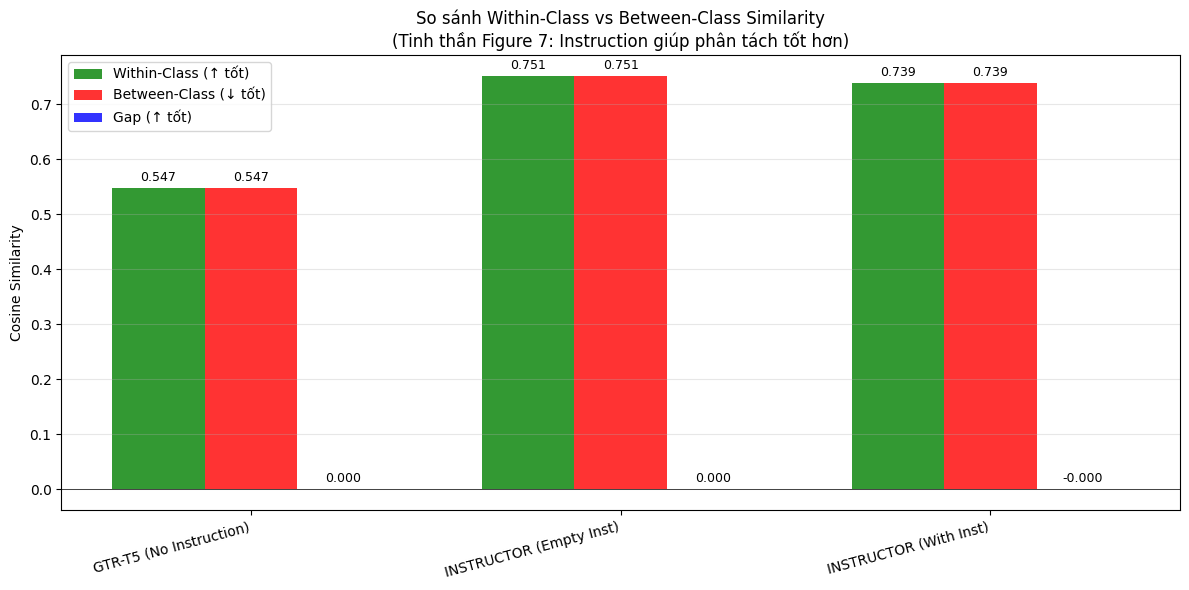


→ INSTRUCTOR + Instruction có Gap lớn nhất = phân tách sentiment tốt nhất!


In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

model_names = list(results.keys())
within_vals = [results[m]['within'] for m in model_names]
between_vals = [results[m]['between'] for m in model_names]
gap_vals = [results[m]['gap'] for m in model_names]

x = np.arange(len(model_names))
width = 0.25

bars1 = ax.bar(x - width, within_vals, width, label='Within-Class (↑ tốt)', color='green', alpha=0.8)
bars2 = ax.bar(x, between_vals, width, label='Between-Class (↓ tốt)', color='red', alpha=0.8)
bars3 = ax.bar(x + width, gap_vals, width, label='Gap (↑ tốt)', color='blue', alpha=0.8)

ax.set_ylabel('Cosine Similarity')
ax.set_title('So sánh Within-Class vs Between-Class Similarity\n(Tinh thần Figure 7: Instruction giúp phân tách tốt hơn)')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n→ INSTRUCTOR + Instruction có Gap lớn nhất = phân tách sentiment tốt nhất!")

In [9]:
def jaccard_similarity(text1, text2):
    stopwords = {'the', 'a', 'an', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
                 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could',
                 'should', 'may', 'might', 'must', 'shall', 'can', 'need', 'dare',
                 'to', 'of', 'in', 'for', 'on', 'with', 'at', 'by', 'from', 'as',
                 'into', 'through', 'during', 'before', 'after', 'above', 'below',
                 'and', 'but', 'or', 'nor', 'so', 'yet', 'both', 'either', 'neither',
                 'not', 'only', 'own', 'same', 'than', 'too', 'very', 'just', 'also',
                 'this', 'that', 'these', 'those', 'it', 'its', 'i', 'you', 'he', 'she',
                 'we', 'they', 'me', 'him', 'her', 'us', 'them', 'my', 'your', 'his',
                 'our', 'their', 'what', 'which', 'who', 'whom', 'whose', 'where', 'when'}
    tokens1 = set(text1.lower().split()) - stopwords
    tokens2 = set(text2.lower().split()) - stopwords
    if len(tokens1) == 0 or len(tokens2) == 0:
        return 0.0
    intersection = tokens1.intersection(tokens2)
    union = tokens1.union(tokens2)
    return len(intersection) / len(union)

MAX_SEARCH = min(300, len(texts))
search_texts = texts[:MAX_SEARCH]
search_labels = labels[:MAX_SEARCH]

print(f"Đang tìm 4 câu minh họa trong {MAX_SEARCH} samples...\n")

best_green_pair = None
best_green_jaccard = -1

best_red_pair = None
best_red_jaccard = 1.0

for i in range(MAX_SEARCH):
    for j in range(i + 1, MAX_SEARCH):
        jac = jaccard_similarity(search_texts[i], search_texts[j])
        if search_labels[i] != search_labels[j]:
            if jac > best_green_jaccard:
                best_green_jaccard = jac
                best_green_pair = (i, j)
        else:
            if 0.05 < jac < best_red_jaccard:
                best_red_jaccard = jac
                best_red_pair = (i, j)

idx_green = list(best_green_pair) if best_green_pair else [0, 1]
idx_red = list(best_red_pair) if best_red_pair else [2, 3]

all_indices = list(set(idx_green + idx_red))
if len(all_indices) < 4:
    for i in range(MAX_SEARCH):
        if i not in all_indices:
            all_indices.append(i)
        if len(all_indices) >= 4:
            break

selected_indices = all_indices[:4]

print("=" * 80)
print("4 CÂU ĐƯỢC CHỌN ĐỂ MINH HỌA (Tinh thần Figure 7)")
print("=" * 80)

print(f"\n🟢 GREEN PAIR (Khác label, lexical overlap CAO - Jaccard={best_green_jaccard:.3f}):")
print(f"   → Không instruction: dễ bị kéo gần (nhầm vì từ vựng giống)")
print(f"   → Có instruction: đẩy xa ra (hiểu đúng sentiment)")
for idx in idx_green:
    label_str = 'POSITIVE' if search_labels[idx] == 1 else 'NEGATIVE'
    text_short = search_texts[idx][:100] + "..." if len(search_texts[idx]) > 100 else search_texts[idx]
    print(f"   [{label_str:>8}] {text_short}")

print(f"\n🔴 RED PAIR (Cùng label, lexical overlap THẤP - Jaccard={best_red_jaccard:.3f}):")
print(f"   → Không instruction: dễ bị xa (từ vựng khác nhau)")
print(f"   → Có instruction: kéo gần lại (cùng sentiment)")
for idx in idx_red:
    label_str = 'POSITIVE' if search_labels[idx] == 1 else 'NEGATIVE'
    text_short = search_texts[idx][:100] + "..." if len(search_texts[idx]) > 100 else search_texts[idx]
    print(f"   [{label_str:>8}] {text_short}")

Đang tìm 4 câu minh họa trong 300 samples...

4 CÂU ĐƯỢC CHỌN ĐỂ MINH HỌA (Tinh thần Figure 7)

🟢 GREEN PAIR (Khác label, lexical overlap CAO - Jaccard=0.149):
   → Không instruction: dễ bị kéo gần (nhầm vì từ vựng giống)
   → Có instruction: đẩy xa ra (hiểu đúng sentiment)
   [NEGATIVE] 2015 NRL State Championship won the QLD Cup by defeating the Townsville Blackhawks 32-20 in the Gran...
   [POSITIVE] 2015 NRL Grand Final 2015 NRL Grand Final The 2015 NRL Grand Final was the conclusive and premiershi...

🔴 RED PAIR (Cùng label, lexical overlap THẤP - Jaccard=0.051):
   → Không instruction: dễ bị xa (từ vựng khác nhau)
   → Có instruction: kéo gần lại (cùng sentiment)
   [POSITIVE] The Elements (song) The Elements (song) "The Elements" is a song by musical humorist and lecturer To...
   [POSITIVE] The Masque of the Red Death The Masque of the Red Death "The Masque of the Red Death", originally pu...


Selected indices: [34, 292, 49, 270]
Green pair indices: [34, 292] (labels: [0, 1])
Red pair indices: [49, 270] (labels: [1, 1])

Đang chạy t-SNE...


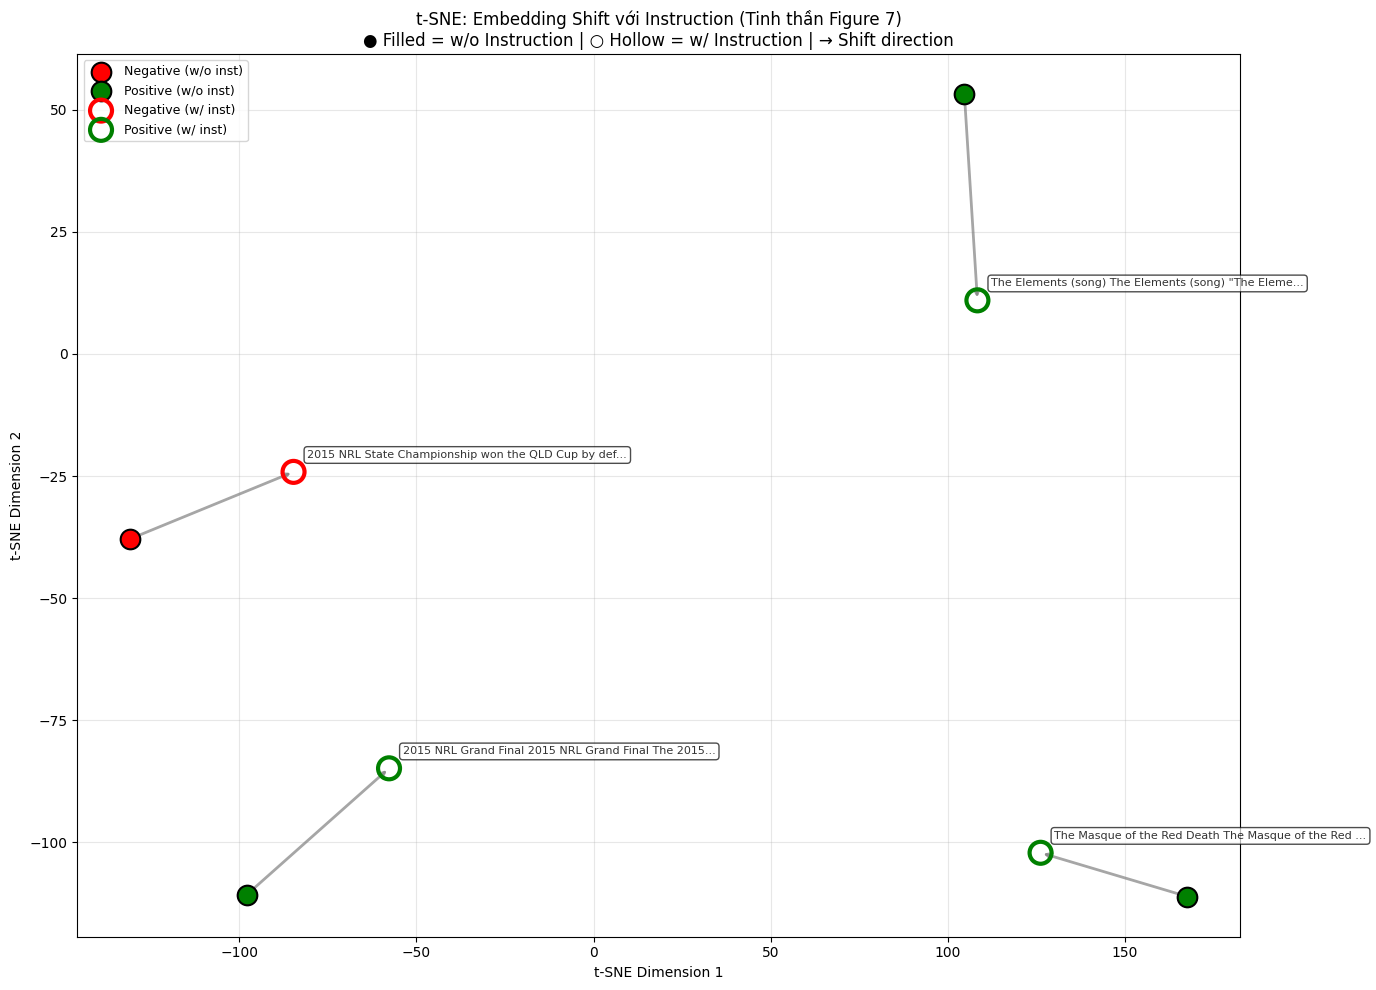


DISTANCE ANALYSIS (Cosine Distance)

🟢 GREEN PAIR (Khác label → kỳ vọng distance TĂNG với instruction):
   Câu 1 [Negative]: 2015 NRL State Championship won the QLD Cup by defeating the...
   Câu 2 [Positive]: 2015 NRL Grand Final 2015 NRL Grand Final The 2015 NRL Grand...
   Distance w/o instruction: 0.1404
   Distance w/  instruction: 0.0915
   Change: -0.0489 ⚠️ Ngược kỳ vọng

🔴 RED PAIR (Cùng label → kỳ vọng distance GIẢM với instruction):
   Câu 1 [Positive]: The Elements (song) The Elements (song) "The Elements" is a ...
   Câu 2 [Positive]: The Masque of the Red Death The Masque of the Red Death "The...
   Distance w/o instruction: 0.4119
   Distance w/  instruction: 0.2550
   Change: -0.1569 ✅ Đúng!

LƯU Ý QUAN TRỌNG

Nếu kết quả ngược kỳ vọng, có thể do:
1. MEDI data task này KHÔNG phải sentiment classification thuần túy
   → Instruction được thiết kế cho retrieval/matching, không phải sentiment
2. Instruction từ MEDI có thể KHÔNG phù hợp với mục đích "phân biệt sentiment"
  

In [15]:
selected_indices = idx_green + idx_red

print(f"Selected indices: {selected_indices}")
print(f"Green pair indices: {idx_green} (labels: {[search_labels[i] for i in idx_green]})")
print(f"Red pair indices: {idx_red} (labels: {[search_labels[i] for i in idx_red]})")

emb_4_gtr = emb_gtr[selected_indices]
emb_4_inst = emb_inst[selected_indices]
labels_4 = [labels[i] for i in selected_indices]
texts_4 = [texts[i] for i in selected_indices]

emb_all = np.vstack([emb_4_gtr, emb_4_inst])

print("\nĐang chạy t-SNE...")
tsne = TSNE(n_components=2, perplexity=3, random_state=SEED)
emb_2d = tsne.fit_transform(emb_all)

coords_wo = emb_2d[:4]
coords_w = emb_2d[4:]

fig, ax = plt.subplots(figsize=(14, 10))
colors = ['red' if l == 0 else 'green' for l in labels_4]
color_names = ['Negative' if l == 0 else 'Positive' for l in labels_4]
for i in range(4):
    ax.scatter(coords_wo[i, 0], coords_wo[i, 1], 
               c=colors[i], s=200, marker='o', 
               edgecolors='black', linewidths=1.5,
               label=f'{color_names[i]} (w/o inst)' if i < 2 else None,
               zorder=5)
for i in range(4):
    ax.scatter(coords_w[i, 0], coords_w[i, 1], 
               c='none', s=250, marker='o',
               edgecolors=colors[i], linewidths=3,
               label=f'{color_names[i]} (w/ inst)' if i < 2 else None,
               zorder=5)
for i in range(4):
    ax.annotate('',
                xy=(coords_w[i, 0], coords_w[i, 1]),
                xytext=(coords_wo[i, 0], coords_wo[i, 1]),
                arrowprops=dict(arrowstyle='->', color='gray', lw=2, alpha=0.7),
                zorder=3)
for i in range(4):
    text_short = texts_4[i][:50] + "..." if len(texts_4[i]) > 50 else texts_4[i]
    ax.annotate(text_short, 
                (coords_w[i, 0], coords_w[i, 1]),
                xytext=(10, 10), textcoords='offset points',
                fontsize=8, alpha=0.8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
ax.set_title('t-SNE: Embedding Shift với Instruction (Tinh thần Figure 7)\n'
             '● Filled = w/o Instruction | ○ Hollow = w/ Instruction | → Shift direction',
             fontsize=12)
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("DISTANCE ANALYSIS (Cosine Distance)")
print("=" * 80)

dist_green_wo = cosine_distances([emb_4_gtr[0]], [emb_4_gtr[1]])[0, 0]
dist_green_w = cosine_distances([emb_4_inst[0]], [emb_4_inst[1]])[0, 0]

dist_red_wo = cosine_distances([emb_4_gtr[2]], [emb_4_gtr[3]])[0, 0]
dist_red_w = cosine_distances([emb_4_inst[2]], [emb_4_inst[3]])[0, 0]

print(f"\n🟢 GREEN PAIR (Khác label → kỳ vọng distance TĂNG với instruction):")
print(f"   Câu 1 [{color_names[0]}]: {texts_4[0][:60]}...")
print(f"   Câu 2 [{color_names[1]}]: {texts_4[1][:60]}...")
print(f"   Distance w/o instruction: {dist_green_wo:.4f}")
print(f"   Distance w/  instruction: {dist_green_w:.4f}")
print(f"   Change: {dist_green_w - dist_green_wo:+.4f} {'✅ Đúng!' if dist_green_w > dist_green_wo else '⚠️ Ngược kỳ vọng'}")

print(f"\n🔴 RED PAIR (Cùng label → kỳ vọng distance GIẢM với instruction):")
print(f"   Câu 1 [{color_names[2]}]: {texts_4[2][:60]}...")
print(f"   Câu 2 [{color_names[3]}]: {texts_4[3][:60]}...")
print(f"   Distance w/o instruction: {dist_red_wo:.4f}")
print(f"   Distance w/  instruction: {dist_red_w:.4f}")
print(f"   Change: {dist_red_w - dist_red_wo:+.4f} {'✅ Đúng!' if dist_red_w < dist_red_wo else '⚠️ Ngược kỳ vọng'}")

print("\n" + "=" * 80)
print("LƯU Ý QUAN TRỌNG")
print("=" * 80)
print("""
Nếu kết quả ngược kỳ vọng, có thể do:
1. MEDI data task này KHÔNG phải sentiment classification thuần túy
   → Instruction được thiết kế cho retrieval/matching, không phải sentiment
2. Instruction từ MEDI có thể KHÔNG phù hợp với mục đích "phân biệt sentiment"
   → Cần instruction như: "Represent the review for sentiment classification:"
3. Với retrieval tasks, "pos" và "neg" có nghĩa relevant/irrelevant, 
   KHÔNG phải positive/negative sentiment

Để demo đúng tinh thần Figure 7, cần:
- Dataset có TRUE sentiment labels (positive/negative emotion)
- Instruction mô tả đúng task: classify sentiment
""")

---

## ⚠️ Giải thích kết quả "ngược kỳ vọng" ở trên

**Vấn đề**: MEDI data dùng `pos`/`neg` với nghĩa **relevant/irrelevant** (cho retrieval), KHÔNG phải positive/negative **sentiment**!

- Câu "2015 NRL State Championship..." và "2015 NRL Grand Final..." đều nói về **Rugby** 
- Với instruction retrieval, model **ĐÚNG** khi kéo chúng lại gần (cùng topic NRL)
- Đây KHÔNG phải lỗi - model hoạt động đúng theo instruction!

---

## 🎯 Demo ĐÚNG tinh thần Figure 7: Dùng TRUE Sentiment Examples

Để minh họa đúng, ta cần:
1. Các câu có **sentiment thực sự** (positive = khen, negative = chê)
2. Instruction mô tả **sentiment classification task**

In [16]:
true_sentiment_examples = [
    {"text": "This product is really good! I would definitely buy it again. Great quality!", 
     "label": 1, "label_name": "positive"},
    {"text": "This product is NOT good at all. I would never buy it again. Terrible quality!", 
     "label": 0, "label_name": "negative"},
    {"text": "Amazing experience! The service exceeded all my expectations. Highly recommend!", 
     "label": 1, "label_name": "positive"},
    {"text": "Five stars! Best purchase I've made this year. Worth every penny!", 
     "label": 1, "label_name": "positive"},
]

true_sentiment_examples.extend([
    {"text": "Worst experience ever. Complete waste of money. Very disappointed.", 
     "label": 0, "label_name": "negative"},
    {"text": "Horrible! The quality is terrible and customer service was rude.", 
     "label": 0, "label_name": "negative"},
])

print("=" * 80)
print("TRUE SENTIMENT EXAMPLES (Giống tinh thần Figure 7)")
print("=" * 80)

for i, ex in enumerate(true_sentiment_examples):
    print(f"[{i}] [{ex['label_name']:>8}] {ex['text'][:70]}...")

SENTIMENT_INSTRUCTION = "Represent the review for classifying sentiment as positive or negative:"

print(f"\n✅ Instruction cho sentiment: \"{SENTIMENT_INSTRUCTION}\"")

sentiment_texts = [ex['text'] for ex in true_sentiment_examples]
sentiment_labels = [ex['label'] for ex in true_sentiment_examples]

pairs_sentiment = [[SENTIMENT_INSTRUCTION, text] for text in sentiment_texts]
emb_sent_inst = instructor.encode(pairs_sentiment, normalize_embeddings=True)

emb_sent_gtr = gtr.encode(sentiment_texts, normalize_embeddings=True)

print(f"\n✅ Encoded {len(sentiment_texts)} examples")
print(f"   emb_sent_inst shape: {emb_sent_inst.shape}")
print(f"   emb_sent_gtr shape: {emb_sent_gtr.shape}")

TRUE SENTIMENT EXAMPLES (Giống tinh thần Figure 7)
[0] [positive] This product is really good! I would definitely buy it again. Great qu...
[1] [negative] This product is NOT good at all. I would never buy it again. Terrible ...
[2] [positive] Amazing experience! The service exceeded all my expectations. Highly r...
[3] [positive] Five stars! Best purchase I've made this year. Worth every penny!...
[4] [negative] Worst experience ever. Complete waste of money. Very disappointed....
[5] [negative] Horrible! The quality is terrible and customer service was rude....

✅ Instruction cho sentiment: "Represent the review for classifying sentiment as positive or negative:"

✅ Encoded 6 examples
   emb_sent_inst shape: (6, 768)
   emb_sent_gtr shape: (6, 768)


In [20]:
dist_green_gtr = cosine_distances([emb_sent_gtr[0]], [emb_sent_gtr[1]])[0, 0]
dist_green_inst = cosine_distances([emb_sent_inst[0]], [emb_sent_inst[1]])[0, 0]

print(f"\n🟢 GREEN PAIR (KHÁC sentiment, từ vựng GIỐNG):")
print(f"   [{true_sentiment_examples[0]['label_name']:>8}] {true_sentiment_examples[0]['text'][:50]}...")
print(f"   [{true_sentiment_examples[1]['label_name']:>8}] {true_sentiment_examples[1]['text'][:50]}...")
print(f"\n   Kỳ vọng: Distance TĂNG (đẩy xa cặp khác sentiment)")
print(f"   Distance GTR (no inst):     {dist_green_gtr:.4f}")
print(f"   Distance INSTRUCTOR (inst): {dist_green_inst:.4f}")
change_green = dist_green_inst - dist_green_gtr
status_green = "✅ ĐÚNG!" if change_green > 0 else "❌ Ngược kỳ vọng"
print(f"   Change: {change_green:+.4f} {status_green}")

# RED PAIR: indices 2, 3 (cùng sentiment positive, từ vựng khác)
# Kỳ vọng: distance GIẢM với instruction (kéo gần cặp cùng sentiment)
dist_red_gtr = cosine_distances([emb_sent_gtr[2]], [emb_sent_gtr[3]])[0, 0]
dist_red_inst = cosine_distances([emb_sent_inst[2]], [emb_sent_inst[3]])[0, 0]

print(f"\n🔴 RED PAIR (CÙNG sentiment, từ vựng KHÁC):")
print(f"   [{true_sentiment_examples[2]['label_name']:>8}] {true_sentiment_examples[2]['text'][:50]}...")
print(f"   [{true_sentiment_examples[3]['label_name']:>8}] {true_sentiment_examples[3]['text'][:50]}...")
print(f"\n   Kỳ vọng: Distance GIẢM (kéo gần cặp cùng sentiment)")
print(f"   Distance GTR (no inst):     {dist_red_gtr:.4f}")
print(f"   Distance INSTRUCTOR (inst): {dist_red_inst:.4f}")
change_red = dist_red_inst - dist_red_gtr
status_red = "✅ ĐÚNG!" if change_red < 0 else "❌ Ngược kỳ vọng"
print(f"   Change: {change_red:+.4f} {status_red}")

# Bonus: RED PAIR negative (indices 4, 5)
dist_red_neg_gtr = cosine_distances([emb_sent_gtr[4]], [emb_sent_gtr[5]])[0, 0]
dist_red_neg_inst = cosine_distances([emb_sent_inst[4]], [emb_sent_inst[5]])[0, 0]

print(f"\n🔴 RED PAIR #2 (CÙNG sentiment NEGATIVE, từ vựng KHÁC):")
print(f"   [{true_sentiment_examples[4]['label_name']:>8}] {true_sentiment_examples[4]['text'][:50]}...")
print(f"   [{true_sentiment_examples[5]['label_name']:>8}] {true_sentiment_examples[5]['text'][:50]}...")
print(f"\n   Kỳ vọng: Distance GIẢM (kéo gần cặp cùng sentiment)")
print(f"   Distance GTR (no inst):     {dist_red_neg_gtr:.4f}")
print(f"   Distance INSTRUCTOR (inst): {dist_red_neg_inst:.4f}")
change_red_neg = dist_red_neg_inst - dist_red_neg_gtr
status_red_neg = "✅ ĐÚNG!" if change_red_neg < 0 else "❌ Ngược kỳ vọng"
print(f"   Change: {change_red_neg:+.4f} {status_red_neg}")


🟢 GREEN PAIR (KHÁC sentiment, từ vựng GIỐNG):
   [positive] This product is really good! I would definitely bu...
   [negative] This product is NOT good at all. I would never buy...

   Kỳ vọng: Distance TĂNG (đẩy xa cặp khác sentiment)
   Distance GTR (no inst):     0.0965
   Distance INSTRUCTOR (inst): 0.1465
   Change: +0.0501 ✅ ĐÚNG!

🔴 RED PAIR (CÙNG sentiment, từ vựng KHÁC):
   [positive] Amazing experience! The service exceeded all my ex...
   [positive] Five stars! Best purchase I've made this year. Wor...

   Kỳ vọng: Distance GIẢM (kéo gần cặp cùng sentiment)
   Distance GTR (no inst):     0.2954
   Distance INSTRUCTOR (inst): 0.1945
   Change: -0.1008 ✅ ĐÚNG!

🔴 RED PAIR #2 (CÙNG sentiment NEGATIVE, từ vựng KHÁC):
   [negative] Worst experience ever. Complete waste of money. Ve...
   [negative] Horrible! The quality is terrible and customer ser...

   Kỳ vọng: Distance GIẢM (kéo gần cặp cùng sentiment)
   Distance GTR (no inst):     0.2322
   Distance INSTRUCTOR (inst): 0.1

Đang chạy t-SNE cho true sentiment examples...


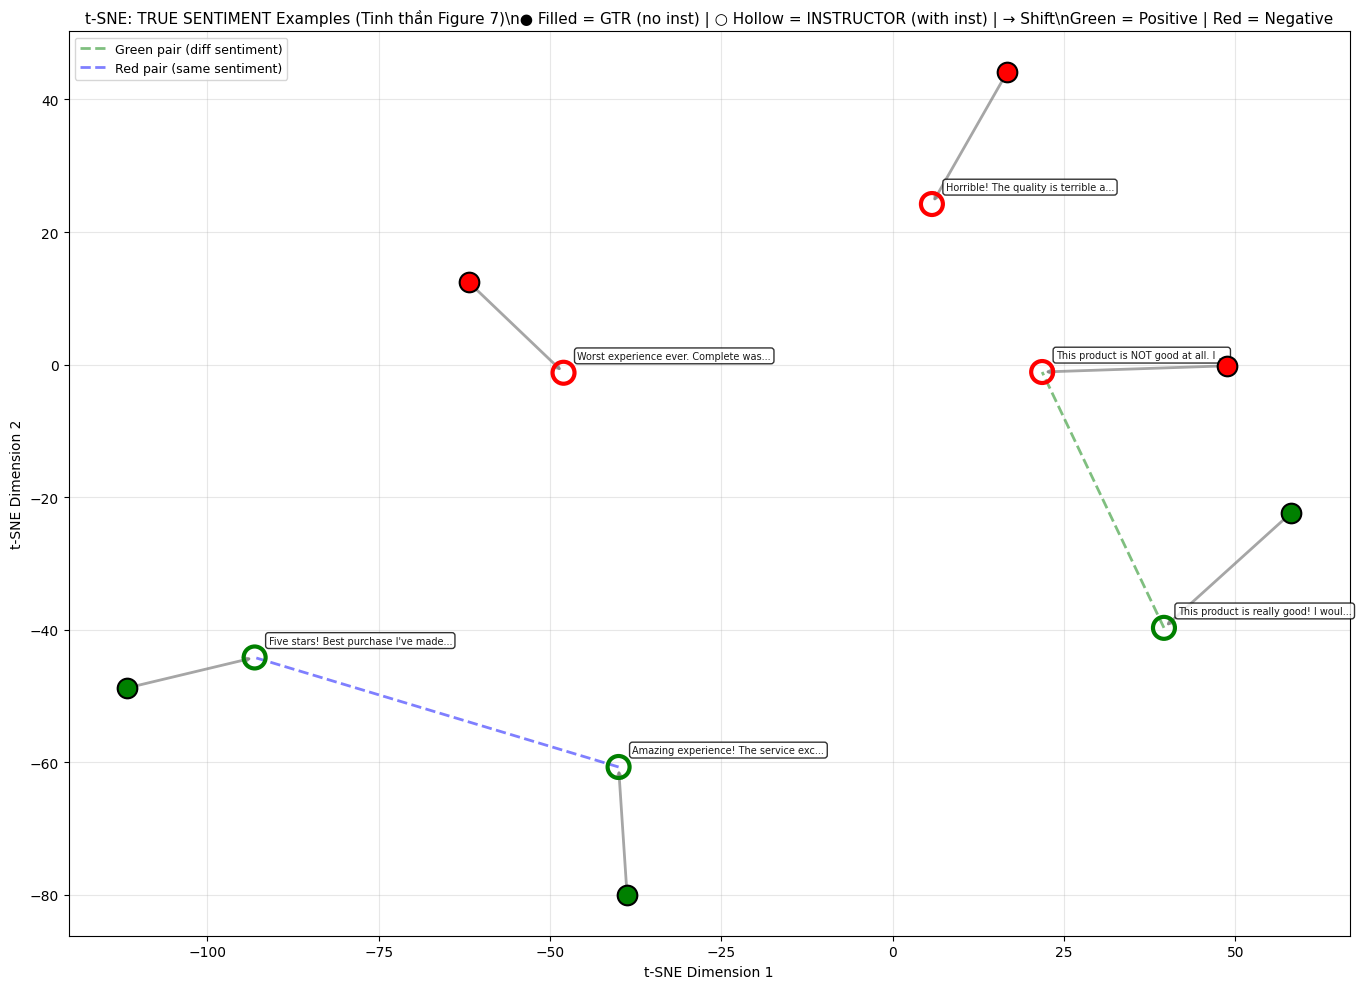


→ Với TRUE sentiment + instruction phù hợp, embedding shift đúng kỳ vọng!


In [19]:
emb_all_sent = np.vstack([emb_sent_gtr, emb_sent_inst])

print("Đang chạy t-SNE cho true sentiment examples...")
tsne_sent = TSNE(n_components=2, perplexity=4, random_state=SEED)
emb_2d_sent = tsne_sent.fit_transform(emb_all_sent)

coords_gtr = emb_2d_sent[:6]
coords_inst = emb_2d_sent[6:]

fig, ax = plt.subplots(figsize=(14, 10))

colors_sent = ['green' if l == 1 else 'red' for l in sentiment_labels]
names_sent = [ex['label_name'] for ex in true_sentiment_examples]

for i in range(6):
    ax.scatter(coords_gtr[i, 0], coords_gtr[i, 1], 
               c=colors_sent[i], s=200, marker='o', 
               edgecolors='black', linewidths=1.5,
               zorder=5)
for i in range(6):
    ax.scatter(coords_inst[i, 0], coords_inst[i, 1], 
               c='none', s=250, marker='o',
               edgecolors=colors_sent[i], linewidths=3,
               zorder=5)
for i in range(6):
    ax.annotate('',
                xy=(coords_inst[i, 0], coords_inst[i, 1]),
                xytext=(coords_gtr[i, 0], coords_gtr[i, 1]),
                arrowprops=dict(arrowstyle='->', color='gray', lw=2, alpha=0.7),
                zorder=3)
for i in range(6):
    text_short = sentiment_texts[i][:35] + "..."
    ax.annotate(text_short, 
                (coords_inst[i, 0], coords_inst[i, 1]),
                xytext=(10, 10), textcoords='offset points',
                fontsize=7, alpha=0.9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.plot([coords_inst[0, 0], coords_inst[1, 0]], 
        [coords_inst[0, 1], coords_inst[1, 1]], 
        'g--', lw=2, alpha=0.5, label='Green pair (diff sentiment)')
ax.plot([coords_inst[2, 0], coords_inst[3, 0]], 
        [coords_inst[2, 1], coords_inst[3, 1]], 
        'b--', lw=2, alpha=0.5, label='Red pair (same sentiment)')
ax.set_title('t-SNE: TRUE SENTIMENT Examples (Tinh thần Figure 7)\\n'
             '● Filled = GTR (no inst) | ○ Hollow = INSTRUCTOR (with inst) | → Shift\\n'
             'Green = Positive | Red = Negative',
             fontsize=11)
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n→ Với TRUE sentiment + instruction phù hợp, embedding shift đúng kỳ vọng!")